# Reainforcement Learning for Snake : Deep-Q Network

## Gymnasium environment

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pygame
import random

In [2]:

class SnakeEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 10}
    def __init__(self, render_mode=None, size=10):
        super().__init__()
        # Paramètres
        self.size = size                # Size of the game grid
        self.render_mode = render_mode  # "human" or None to toggle or untoggle rendering
        self.steps_without_food = 0     # Will be useful to prune episodes where the snake is stuck in a loop
        # The heart of the gym environnement
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Box(low=0, high=3, shape=(self.size, self.size), dtype=np.uint8)
        # Pygame
        self.window = None
        self.clock = None
        

    def _generate_random_snake(self, snake_size):
        """
        Generates a snake of size `snake_size` thanks to DFS with Backtracking.
        Returns the list of the snake's coordinates along with its cinematically correct initial direction.
        """
        def dfs(current_path):
            # Stop codition : the snake has reached its desired length
            if len(current_path) == snake_size:
                return current_path
            
            # We extend the snake from its previously added segment (its tail)
            tail_r, tail_c = current_path[-1]
            
            # Shuffling directions to guaranty random shapes at each generation
            directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
            random.shuffle(directions)
            
            for dr, dc in directions:
                nr, nc = tail_r + dr, tail_c + dc
                
                # Assertion of grid's limits and collisions
                if 0 <= nr < self.size and 0 <= nc < self.size:
                    if [nr, nc] not in current_path:
                        # Recursive call (Backtracking)
                        result = dfs(current_path + [[nr, nc]])
                        if result:
                            return result
            return None

        # Security loop for the case where the random start point is topologically impossible.
        while True:
            start_r = random.randint(0, self.size - 1)
            start_c = random.randint(0, self.size - 1)
            
            snake_path = dfs([[start_r, start_c]])
            
            if snake_path:
                # Inverting the path ; the DFS start point becomes the tail, the last point becomes the head.
                # It allows calculating the direction vector  of the snake's head easily.
                snake = snake_path[::-1]
                
                # Calculating the valid initial direction
                head = snake[0]
                neck = snake[1]
                
                # Coordinates of the direction vector
                dr = head[0] - neck[0]
                dc = head[1] - neck[1]
                
                direction = 3 # Default value as a security
                if dr == -1 and dc == 0: direction = 0   # Haut
                elif dr == 1 and dc == 0: direction = 1  # Bas
                elif dr == 0 and dc == -1: direction = 2 # Gauche
                elif dr == 0 and dc == 1: direction = 3  # Droite
                
                return snake, direction
        
    def reset(self, snake_size=3):
        super().reset()
        self.steps_without_food = 0
        self.snake, self.direction = self._generate_random_snake(snake_size)
        self.apple = self._generate_apple()
        observation = self._get_obs()
        info = {}
        return observation, info
    
    def step(self, action):
        self.direction = action
        self.steps_without_food += 1
        
        head = self.snake[0].copy()
        if self.direction == 0: head[0] -= 1 # Up
        if self.direction == 1: head[0] += 1 # Down
        if self.direction == 2: head[1] -= 1 # Left
        if self.direction == 3: head[1] += 1 # Right
        
        terminated = False
        truncated = False
        reward = 0
        if head[0]<0 or head[0]>=self.size or head[1]<0 or head[1]>=self.size or (head in self.snake and head != self.snake[-1]):
            terminated = True
            reward = -10
        else :
            self.snake.insert(0, head)
            if head == self.apple :
                self.steps_without_food = 0
                if len(self.snake) == self.size * self.size:
                    terminated = True
                    reward = 100  # Victory : the grid has been filled by the snake
                    self.apple = [-1, -1]  # Fictive coordinate to avoid a crash in _get_obs or render
                else:
                    reward = 10
                    self.apple = self._generate_apple()
            else :
                self.snake.pop()
                reward = -0.05
                
        # Death condition from starvation (to avoid loops) (Truncated)
        if self.steps_without_food > 100:
            truncated = True
            reward = -10 # Penalty for having lost time
                
        observation = self._get_obs()
        
        
        if self.render_mode == "human":
            self.render()
            
        info = {"snake_length": len(self.snake)}
        
        return observation, reward, terminated, truncated, info
    
    def _generate_apple(self):
        all_positions = {(r, c) for r in range(self.size) for c in range(self.size)}
        occupied = {tuple(p) for p in self.snake}
        empty_cells = list(all_positions - occupied)
        r,c = random.choice(empty_cells)
        return [r, c]
    
    def _update_direction(self, action):
        is_allowed = (action%2==0 and self.direction != action + 1) or (action%2==1 and self.direction != action - 1)
        self.direction = action*is_allowed + self.direction*(1-is_allowed)
        return None

    def _get_obs(self):
        grid = np.zeros((3, self.size, self.size), dtype=np.uint8)
        for part in self.snake[1:]:
            grid[0][part[0], part[1]] = 1
        grid[1][self.snake[0][0], self.snake[0][1]] = 1 # Head
        grid[2][self.apple[0], self.apple[1]] = 1 # Apple
        direction = [0, 0, 0, 0]
        direction[self.direction] = 1
        return grid, direction
    
    def render(self):
        if self.window is None:
            pygame.init()
            pygame.display.init()
            self.window_size = 400
            self.cell_size = self.window_size // self.size # 40 pixels per cell for a 10x10 grid
            self.window = pygame.display.set_mode((self.window_size, self.window_size))
            pygame.display.set_caption("Snake AI - Gymnasium")
            self.clock = pygame.time.Clock()
        
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                self.close()
            
        self.window.fill((0, 0, 0))
        
        for i, part in enumerate(self.snake):
            color = (0, 255, 0) if i == 0 else (0, 200, 0)
            rect = pygame.Rect(part[1] * self.cell_size, part[0] * self.cell_size, self.cell_size, self.cell_size)
            pygame.draw.rect(self.window, color, rect)
            
        if self.apple:
            apple_rect = pygame.Rect(self.apple[1] * self.cell_size, self.apple[0] * self.cell_size, self.cell_size, self.cell_size)
            pygame.draw.rect(self.window, (255, 0, 0), apple_rect)
            
        pygame.display.flip()
        self.clock.tick(self.metadata["render_fps"])
        
        if self.render_mode == "rgb_array":
            pixel_array = pygame.surfarray.array3d(self.window)
            pixel_array = np.transpose(pixel_array, axes=(1, 0, 2))
            return pixel_array
        
        

    def close(self):
        if self.window is not None:
            pygame.display.quit()
            pygame.quit()
    

## Replay buffer

In [3]:
from collections import deque

In [4]:
class ReplayBuffer:
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        # Storing the transition (s, a, r, s', d)
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        # Random sampling for training
        return random.sample(self.buffer, batch_size)
    
    def __len__(self):
        return len(self.buffer)

## Deep-Q Network

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [6]:
class DQN(nn.Module):
    """This architecture has been designed to work for a 10x10 grid."""
    
    def __init__(self, size=10, n_actions=4):
        super(DQN, self).__init__()
        
        self.conv1 = torch.nn.Conv2d(3, 64, 5, padding='same')
        self.conv2 = torch.nn.Conv2d(64, 64, 5, padding='same') 
        
        self.linear1 = torch.nn.Linear(256+4, 128)
        self.linear2 = torch.nn.Linear(128, 128)
        self.linear3 = torch.nn.Linear(128, n_actions)
        
        self.flatten = torch.nn.Flatten()
        self.maxpool = torch.nn.MaxPool2d(2)
        self.relu = torch.nn.ReLU()

    def forward(self, x, direction):
        
        if x.dim() == 3:
            x = x.unsqueeze(1)
        if direction.dim() == 3:
            direction = direction.unsqueeze(1)

        x = x.float()
        direction = direction.float()
        
        x = self.conv1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = x.view(-1, 256)
        x = torch.cat((x, direction), dim=1)
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.relu(x)
        x = self.linear3(x)
        return x

## Training

In [57]:
import torch.optim as optim

In [58]:
# Hyperparameters
LR = 1e-4
BATCH_SIZE = 256
GAMMA = 0.99            # Futur reward reduction factor
EPS_START = 0.9         # Exploration rate at the beginning
EPS_END = 0.1           # Minimum exploration rate
EPS_DECAY = 5000        # Caracteristic exploration duration 
TAU = 0.005             # Smooth update factor for target_net
SNAKE_SIZE = 3

In [59]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Réseaux
policy_net = DQN(n_actions=4).to(device)
target_net = DQN(n_actions=4).to(device)
target_net.load_state_dict(policy_net.state_dict())


criterion = nn.MSELoss()
memory = ReplayBuffer(100000)

In [60]:
optimizer = optim.Adam(policy_net.parameters(), lr=LR)

In [61]:
def select_action(state):
    global steps_done
    EPS = EPS_END + (EPS_START - EPS_END)*np.exp(-steps_done/EPS_DECAY)
    if steps_done%1000==0 : print(f"steps done = {steps_done} and EPS = {EPS}")
    steps_done += 1
    n = np.random.random()
    if n>EPS :
        with torch.no_grad() :
            grid, direction = state
            grid_t = torch.tensor(grid, device=device).unsqueeze(0)
            dir_t = torch.tensor(direction, device=device).unsqueeze(0)
            Q_s_a = policy_net(grid_t, dir_t)
        return Q_s_a.argmax().item()
    else :
        return env.action_space.sample()
    
def optimize_model(memory):
    loss=0
    if BATCH_SIZE>len(memory):
        return
    transitions = memory.sample(BATCH_SIZE)
    s, a, r, s_next, d = zip(*transitions)
    
    grids = np.array([state[0] for state in s])
    dirs = np.array([state[1] for state in s])
    grid_b = torch.tensor(grids, device=device)
    dir_b = torch.tensor(dirs, device=device)
    
    next_grids = np.array([state[0] for state in s_next])
    next_dirs = np.array([state[1] for state in s_next])
    next_grid_b = torch.tensor(next_grids, device=device)
    next_dir_b = torch.tensor(next_dirs, device=device)
    
    action_b = torch.tensor(a, device=device).unsqueeze(1) # [BATCH, 1]
    reward_b = torch.tensor(r, device=device).float()
    done_b = torch.tensor(d, device=device).float()
    
    q_current = policy_net(grid_b, dir_b).gather(1, action_b)
    
    with torch.no_grad():
        max_next_q = target_net(next_grid_b, next_dir_b).max(1)[0]
        q_target = (reward_b + (1 - done_b) * GAMMA * max_next_q).unsqueeze(1)
    
    loss = criterion(q_current, q_target)
    
    optimizer.zero_grad()
    loss.backward()
    # # À ajouter temporairement dans optimize_model
    # if steps_done % 100 == 0:
    #     print(f"Calcul en cours sur : {next(policy_net.parameters()).device}")
    optimizer.step()
    
    # Mise à jour du target_net
    target_net_state_dict = target_net.state_dict()
    policy_net_state_dict = policy_net.state_dict()

    for key in policy_net_state_dict:
        target_net_state_dict[key] = policy_net_state_dict[key] * TAU + target_net_state_dict[key] * (1 - TAU)
                                    
    target_net.load_state_dict(target_net_state_dict)

In [62]:
import matplotlib.pyplot as plt

In [63]:

def plot_progress(lengths):
    plt.figure(figsize=(10, 5))
    plt.plot(lengths, label="Longueur réelle", alpha=0.3, color='blue')
    
    # Calcul de la moyenne mobile sur 10 épisodes pour voir la tendance
    if len(lengths) > 10:
        means = [np.mean(lengths[max(0, i-10):i+1]) for i in range(len(lengths))]
        plt.plot(means, label="Moyenne mobile (10)", color='red', linewidth=2)
    
    plt.title("Progression de la longueur du serpent")
    plt.xlabel("Épisodes")
    plt.ylabel("Longueur")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

## Training loop

In [64]:
# This cell is here to be able to tweak hyperparameters during different training phases
# Hyperparameters
LR = 1e-4
BATCH_SIZE = 256
GAMMA = 0.99            # Futur reward reduction factor
EPS_START = 0.9         # Exploration rate at the beginning
EPS_END = 0.1           # Minimum exploration rate
EPS_DECAY = 5000        # Caracteristic exploration duration 
TAU = 0.005             # Smooth update factor for target_net
SNAKE_SIZE = 3

In [65]:
history_lengths = []
steps_done = 0

### Single loop

In [ ]:
env = SnakeEnv(render_mode=None)
num_episodes = 1001
max_steps_per_episode = 500

target_net.train()
policy_net.train()

for i_episode in range(num_episodes):
    state, info = env.reset(snake_size=SNAKE_SIZE)    
    for t in range(max_steps_per_episode):
        action = select_action(state)

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        memory.push(state, action, reward, next_state, done)

        state = next_state

        optimize_model(memory)

        if done :
            current_length = len(env.snake) 
            history_lengths.append(current_length)
            break
        
    print(f"Episode {i_episode} terminé")
    if i_episode%1000==0 :
        plot_progress(history_lengths)

### Complete training

Starting training phase number 1 with epsilon starting at 0.9
steps done = 0 and EPS = 0.9
Episode 0 terminé
Episode 1 terminé
Episode 2 terminé
Episode 3 terminé
Episode 4 terminé
Episode 5 terminé
Episode 6 terminé
Episode 7 terminé
Episode 8 terminé
Episode 9 terminé
Episode 10 terminé
Episode 11 terminé
Episode 12 terminé
Episode 13 terminé
Episode 14 terminé
Episode 15 terminé
Episode 16 terminé
Episode 17 terminé
Episode 18 terminé
Episode 19 terminé
Episode 20 terminé
Episode 21 terminé
Episode 22 terminé
Episode 23 terminé
Episode 24 terminé
Episode 25 terminé
Episode 26 terminé
Episode 27 terminé
Episode 28 terminé
Episode 29 terminé
Episode 30 terminé
Episode 31 terminé
Episode 32 terminé
Episode 33 terminé
Episode 34 terminé
Episode 35 terminé
Episode 36 terminé
Episode 37 terminé
Episode 38 terminé
Episode 39 terminé
Episode 40 terminé
Episode 41 terminé
Episode 42 terminé
Episode 43 terminé
Episode 44 terminé
Episode 45 terminé
Episode 46 terminé
Episode 47 terminé
Episode

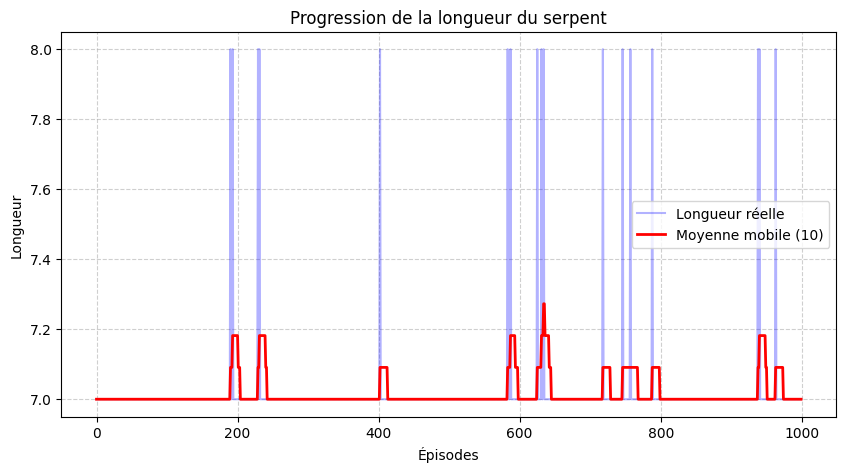

Episode 1000 terminé
Episode 1001 terminé
Episode 1002 terminé
Episode 1003 terminé
Episode 1004 terminé
Episode 1005 terminé
Episode 1006 terminé
Episode 1007 terminé
Episode 1008 terminé
Episode 1009 terminé
Episode 1010 terminé
Episode 1011 terminé
Episode 1012 terminé
Episode 1013 terminé
Episode 1014 terminé
Episode 1015 terminé
Episode 1016 terminé
Episode 1017 terminé
Episode 1018 terminé
Episode 1019 terminé
Episode 1020 terminé
Episode 1021 terminé
Episode 1022 terminé
Episode 1023 terminé
Episode 1024 terminé
Episode 1025 terminé
Episode 1026 terminé
Episode 1027 terminé
Episode 1028 terminé
Episode 1029 terminé
Episode 1030 terminé
Episode 1031 terminé
Episode 1032 terminé
Episode 1033 terminé
Episode 1034 terminé
Episode 1035 terminé
Episode 1036 terminé
Episode 1037 terminé
Episode 1038 terminé
Episode 1039 terminé
Episode 1040 terminé
Episode 1041 terminé
Episode 1042 terminé
Episode 1043 terminé
Episode 1044 terminé
Episode 1045 terminé
Episode 1046 terminé
Episode 1047 

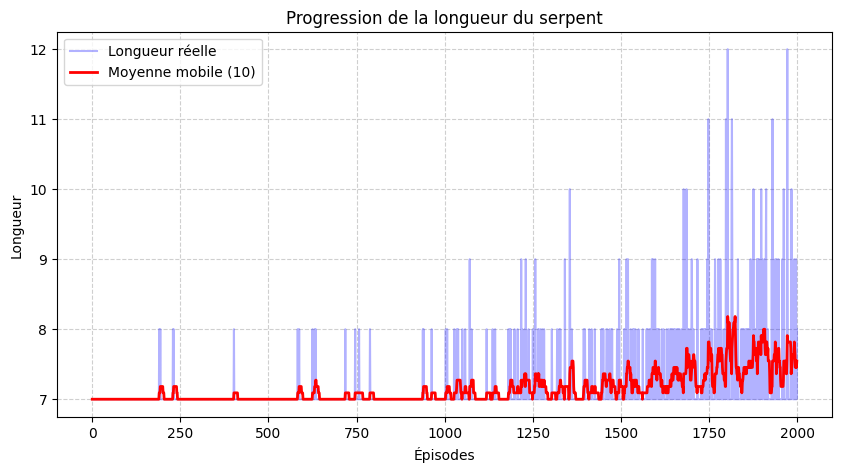

Episode 2000 terminé
Episode 2001 terminé
Episode 2002 terminé
Episode 2003 terminé
Episode 2004 terminé
Episode 2005 terminé
Episode 2006 terminé
Episode 2007 terminé
Episode 2008 terminé
Episode 2009 terminé
Episode 2010 terminé
Episode 2011 terminé
Episode 2012 terminé
Episode 2013 terminé
Episode 2014 terminé
Episode 2015 terminé
Episode 2016 terminé
Episode 2017 terminé
Episode 2018 terminé
Episode 2019 terminé
Episode 2020 terminé
Episode 2021 terminé
Episode 2022 terminé
Episode 2023 terminé
Episode 2024 terminé
Episode 2025 terminé
Episode 2026 terminé
Episode 2027 terminé
steps done = 16000 and EPS = 0.13260976318269296
Episode 2028 terminé
Episode 2029 terminé
Episode 2030 terminé
Episode 2031 terminé
Episode 2032 terminé
Episode 2033 terminé
Episode 2034 terminé
Episode 2035 terminé
Episode 2036 terminé
Episode 2037 terminé
Episode 2038 terminé
Episode 2039 terminé
Episode 2040 terminé
Episode 2041 terminé
Episode 2042 terminé
Episode 2043 terminé
Episode 2044 terminé
Episod

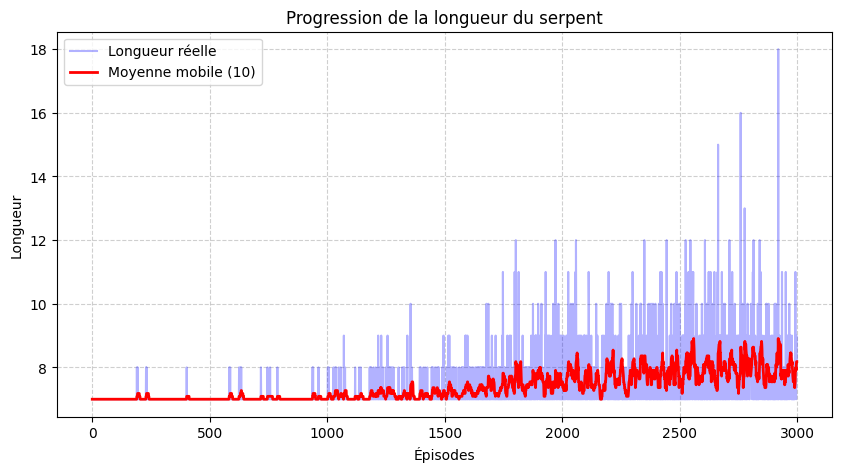

Phase 0 duration : 176.35165572166443 seconds
Starting training phase number 2 with epsilon starting at 0.3
steps done = 0 and EPS = 0.3
Episode 0 terminé
Episode 1 terminé
Episode 2 terminé
Episode 3 terminé
Episode 4 terminé
Episode 5 terminé
Episode 6 terminé
Episode 7 terminé
Episode 8 terminé
Episode 9 terminé
Episode 10 terminé
Episode 11 terminé
Episode 12 terminé
Episode 13 terminé
Episode 14 terminé
Episode 15 terminé
Episode 16 terminé
Episode 17 terminé
Episode 18 terminé
Episode 19 terminé
Episode 20 terminé
Episode 21 terminé
Episode 22 terminé
Episode 23 terminé
Episode 24 terminé
Episode 25 terminé
Episode 26 terminé
Episode 27 terminé
Episode 28 terminé
Episode 29 terminé
Episode 30 terminé
Episode 31 terminé
Episode 32 terminé
Episode 33 terminé
Episode 34 terminé
Episode 35 terminé
Episode 36 terminé
Episode 37 terminé
Episode 38 terminé
Episode 39 terminé
Episode 40 terminé
Episode 41 terminé
Episode 42 terminé
Episode 43 terminé
Episode 44 terminé
Episode 45 terminé

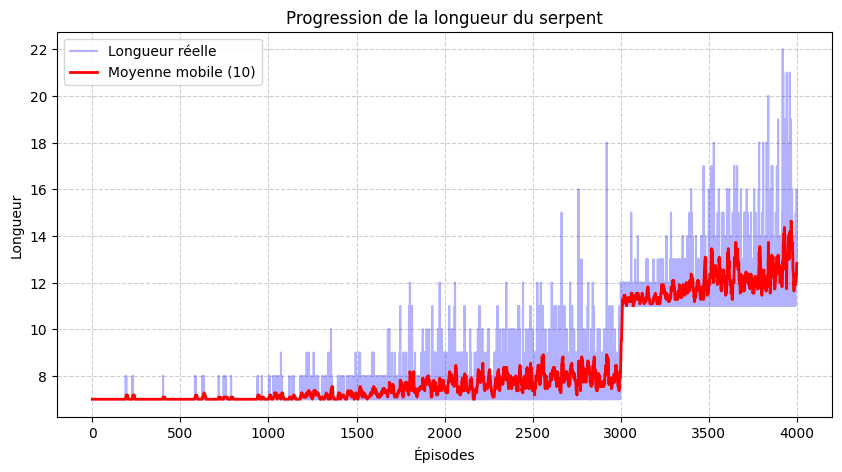

Episode 1000 terminé
Episode 1001 terminé
Episode 1002 terminé
Episode 1003 terminé
steps done = 28000 and EPS = 0.050227970491388635
Episode 1004 terminé
Episode 1005 terminé
Episode 1006 terminé
Episode 1007 terminé
Episode 1008 terminé
Episode 1009 terminé
Episode 1010 terminé
Episode 1011 terminé
Episode 1012 terminé
Episode 1013 terminé
Episode 1014 terminé
Episode 1015 terminé
Episode 1016 terminé
Episode 1017 terminé
Episode 1018 terminé
Episode 1019 terminé
Episode 1020 terminé
Episode 1021 terminé
Episode 1022 terminé
steps done = 29000 and EPS = 0.05017754359721064
Episode 1023 terminé
Episode 1024 terminé
Episode 1025 terminé
Episode 1026 terminé
Episode 1027 terminé
Episode 1028 terminé
Episode 1029 terminé
Episode 1030 terminé
Episode 1031 terminé
Episode 1032 terminé
Episode 1033 terminé
Episode 1034 terminé
Episode 1035 terminé
Episode 1036 terminé
Episode 1037 terminé
Episode 1038 terminé
Episode 1039 terminé
Episode 1040 terminé
Episode 1041 terminé
Episode 1042 termin

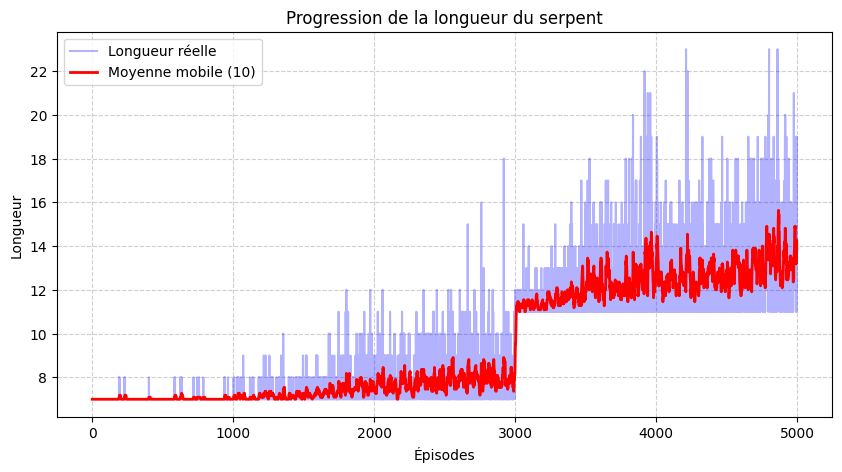

Phase 1 duration : 1775421854.6955547 seconds
Starting training phase number 3 with epsilon starting at 0.3
steps done = 0 and EPS = 0.3
Episode 0 terminé
Episode 1 terminé
Episode 2 terminé
Episode 3 terminé
Episode 4 terminé
Episode 5 terminé
Episode 6 terminé
Episode 7 terminé
Episode 8 terminé
Episode 9 terminé
Episode 10 terminé
Episode 11 terminé
Episode 12 terminé
Episode 13 terminé
Episode 14 terminé
Episode 15 terminé
Episode 16 terminé
Episode 17 terminé
Episode 18 terminé
Episode 19 terminé
Episode 20 terminé
Episode 21 terminé
Episode 22 terminé
Episode 23 terminé
Episode 24 terminé
Episode 25 terminé
Episode 26 terminé
Episode 27 terminé
Episode 28 terminé
Episode 29 terminé
Episode 30 terminé
Episode 31 terminé
Episode 32 terminé
Episode 33 terminé
Episode 34 terminé
Episode 35 terminé
Episode 36 terminé
Episode 37 terminé
Episode 38 terminé
Episode 39 terminé
Episode 40 terminé
Episode 41 terminé
Episode 42 terminé
Episode 43 terminé
Episode 44 terminé
Episode 45 terminé

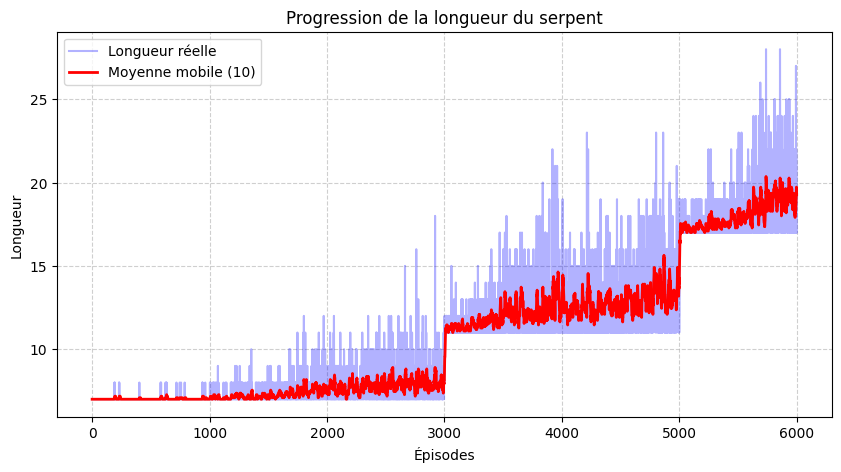

Phase 2 duration : 276.60764265060425 seconds
Starting training phase number 4 with epsilon starting at 0.3
steps done = 0 and EPS = 0.3
Episode 0 terminé
Episode 1 terminé
Episode 2 terminé
Episode 3 terminé
Episode 4 terminé
Episode 5 terminé
Episode 6 terminé
Episode 7 terminé
Episode 8 terminé
Episode 9 terminé
Episode 10 terminé
Episode 11 terminé
Episode 12 terminé
Episode 13 terminé
Episode 14 terminé
Episode 15 terminé
Episode 16 terminé
Episode 17 terminé
Episode 18 terminé
Episode 19 terminé
Episode 20 terminé
Episode 21 terminé
Episode 22 terminé
Episode 23 terminé
Episode 24 terminé
Episode 25 terminé
Episode 26 terminé
Episode 27 terminé
Episode 28 terminé
Episode 29 terminé
Episode 30 terminé
Episode 31 terminé
Episode 32 terminé
Episode 33 terminé
Episode 34 terminé
Episode 35 terminé
Episode 36 terminé
Episode 37 terminé
Episode 38 terminé
Episode 39 terminé
Episode 40 terminé
Episode 41 terminé
Episode 42 terminé
Episode 43 terminé
Episode 44 terminé
Episode 45 terminé

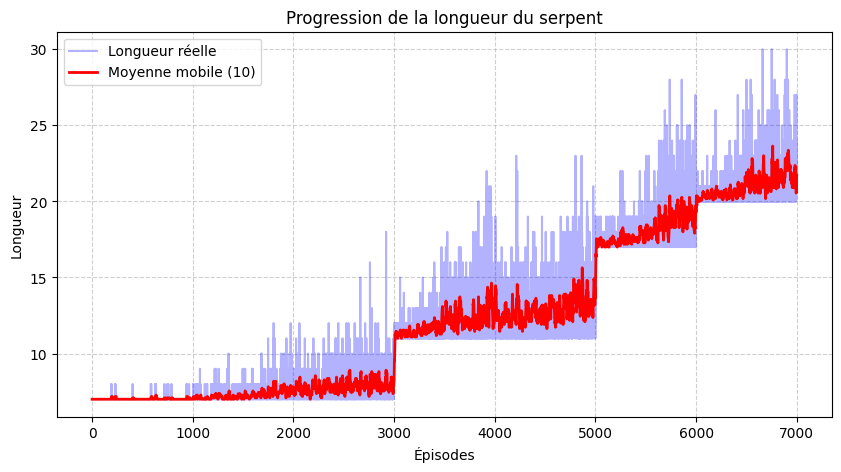

Phase 3 duration : 1775421949.3684008 seconds
Starting training phase number 5 with epsilon starting at 0.3
steps done = 0 and EPS = 0.3
Episode 0 terminé
Episode 1 terminé
Episode 2 terminé
Episode 3 terminé
Episode 4 terminé
Episode 5 terminé
Episode 6 terminé
Episode 7 terminé
Episode 8 terminé
Episode 9 terminé
Episode 10 terminé
Episode 11 terminé
Episode 12 terminé
Episode 13 terminé
Episode 14 terminé
Episode 15 terminé
Episode 16 terminé
Episode 17 terminé
Episode 18 terminé
Episode 19 terminé
Episode 20 terminé
Episode 21 terminé
Episode 22 terminé
Episode 23 terminé
Episode 24 terminé
Episode 25 terminé
Episode 26 terminé
Episode 27 terminé
Episode 28 terminé
Episode 29 terminé
Episode 30 terminé
Episode 31 terminé
Episode 32 terminé
Episode 33 terminé
Episode 34 terminé
Episode 35 terminé
Episode 36 terminé
Episode 37 terminé
Episode 38 terminé
Episode 39 terminé
Episode 40 terminé
Episode 41 terminé
Episode 42 terminé
Episode 43 terminé
Episode 44 terminé
Episode 45 terminé

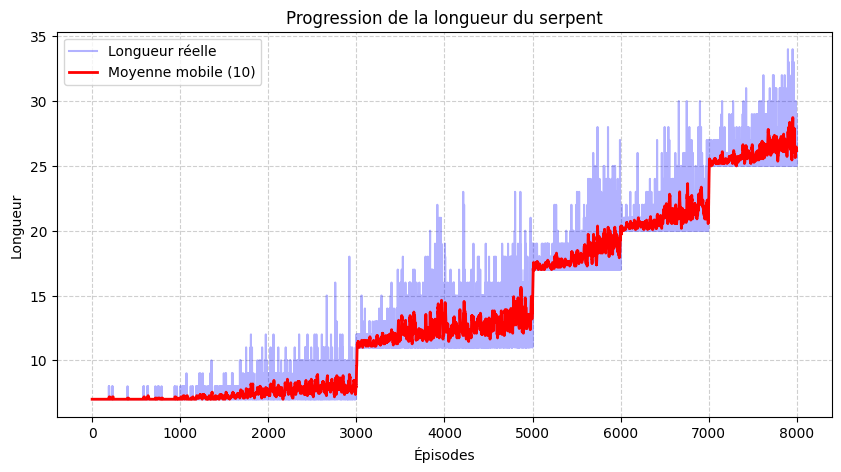

Phase 4 duration : 366.61223220825195 seconds
Starting training phase number 6 with epsilon starting at 0.3
steps done = 0 and EPS = 0.3
Episode 0 terminé
Episode 1 terminé
Episode 2 terminé
Episode 3 terminé
Episode 4 terminé
Episode 5 terminé
Episode 6 terminé
Episode 7 terminé
Episode 8 terminé
Episode 9 terminé
Episode 10 terminé
Episode 11 terminé
Episode 12 terminé
Episode 13 terminé
Episode 14 terminé
Episode 15 terminé
Episode 16 terminé
Episode 17 terminé
Episode 18 terminé
Episode 19 terminé
Episode 20 terminé
Episode 21 terminé
Episode 22 terminé
Episode 23 terminé
Episode 24 terminé
Episode 25 terminé
Episode 26 terminé
Episode 27 terminé
Episode 28 terminé
Episode 29 terminé
Episode 30 terminé
Episode 31 terminé
Episode 32 terminé
Episode 33 terminé
Episode 34 terminé
Episode 35 terminé
Episode 36 terminé
Episode 37 terminé
Episode 38 terminé
Episode 39 terminé
Episode 40 terminé
Episode 41 terminé
Episode 42 terminé
Episode 43 terminé
Episode 44 terminé
Episode 45 terminé

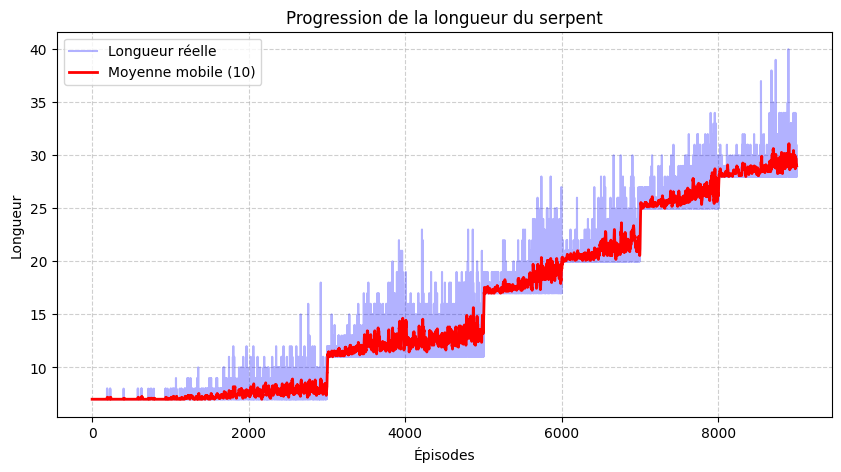

Phase 5 duration : 1775422027.2666306 seconds
Starting training phase number 7 with epsilon starting at 0.3
steps done = 0 and EPS = 0.3
Episode 0 terminé
Episode 1 terminé
Episode 2 terminé
Episode 3 terminé
Episode 4 terminé
Episode 5 terminé
Episode 6 terminé
Episode 7 terminé
Episode 8 terminé
Episode 9 terminé
Episode 10 terminé
Episode 11 terminé
Episode 12 terminé
Episode 13 terminé
Episode 14 terminé
Episode 15 terminé
Episode 16 terminé
Episode 17 terminé
Episode 18 terminé
Episode 19 terminé
Episode 20 terminé
Episode 21 terminé
Episode 22 terminé
Episode 23 terminé
Episode 24 terminé
Episode 25 terminé
Episode 26 terminé
Episode 27 terminé
Episode 28 terminé
Episode 29 terminé
Episode 30 terminé
Episode 31 terminé
Episode 32 terminé
Episode 33 terminé
Episode 34 terminé
Episode 35 terminé
Episode 36 terminé
Episode 37 terminé
Episode 38 terminé
Episode 39 terminé
Episode 40 terminé
Episode 41 terminé
Episode 42 terminé
Episode 43 terminé
Episode 44 terminé
Episode 45 terminé

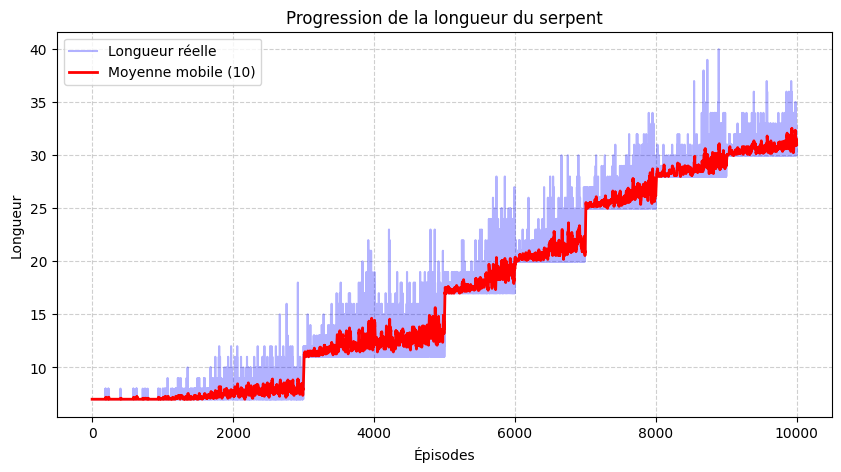

Phase 6 duration : 436.86988496780396 seconds


In [66]:
import time

env = SnakeEnv(render_mode=None)
max_steps_per_episode = 500
phases = [{'num_episodes': 3000, 'LR': 1e-4, 'BATCH_SIZE': 256, 'GAMMA': 0.99,
           'EPS_START': 0.9, 'EPS_END': 0.1, 'EPS_DECAY': 5000, 'TAU': 0.005, 'SNAKE_SIZE': 7},
          {'num_episodes': 2000, 'LR': 1e-4, 'BATCH_SIZE': 256, 'GAMMA': 0.99,
           'EPS_START': 0.3, 'EPS_END': 0.05, 'EPS_DECAY': 4000, 'TAU': 0.005, 'SNAKE_SIZE': 11},
          {'num_episodes': 1000, 'LR': 1e-4, 'BATCH_SIZE': 256, 'GAMMA': 0.99,
           'EPS_START': 0.3, 'EPS_END': 0.05, 'EPS_DECAY': 4000, 'TAU': 0.005, 'SNAKE_SIZE': 17},
          {'num_episodes': 1000, 'LR': 1e-4, 'BATCH_SIZE': 256, 'GAMMA': 0.99,
           'EPS_START': 0.3, 'EPS_END': 0.05, 'EPS_DECAY': 4000, 'TAU': 0.005, 'SNAKE_SIZE': 20},
          {'num_episodes': 1000, 'LR': 1e-4, 'BATCH_SIZE': 256, 'GAMMA': 0.99,
           'EPS_START': 0.3, 'EPS_END': 0.05, 'EPS_DECAY': 4000, 'TAU': 0.005, 'SNAKE_SIZE': 25},
          {'num_episodes': 1000, 'LR': 1e-4, 'BATCH_SIZE': 256, 'GAMMA': 0.99,
           'EPS_START': 0.3, 'EPS_END': 0.05, 'EPS_DECAY': 4000, 'TAU': 0.005, 'SNAKE_SIZE': 28},
          {'num_episodes': 1000, 'LR': 1e-4, 'BATCH_SIZE': 256, 'GAMMA': 0.99,
           'EPS_START': 0.3, 'EPS_END': 0.05, 'EPS_DECAY': 4000, 'TAU': 0.005, 'SNAKE_SIZE': 30}]



target_net.train()
policy_net.train()
start_time = time.time()

for phase_number, phase in enumerate(phases) :
    
    LR = phase['LR']
    BATCH_SIZE = phase['BATCH_SIZE']
    GAMMA = phase['GAMMA']
    EPS_START = phase['EPS_START']
    EPS_END = phase['EPS_END']
    EPS_DECAY = phase['EPS_DECAY']
    TAU = phase['TAU']
    SNAKE_SIZE = phase['SNAKE_SIZE']
    num_episodes = phase['num_episodes']
    steps_done = 0

    print(f"Starting training phase number {phase_number+1} with epsilon starting at {EPS_START}")
    for i_episode in range(num_episodes):
        state, info = env.reset(snake_size=SNAKE_SIZE)    
        for t in range(max_steps_per_episode):
            action = select_action(state)

            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            memory.push(state, action, reward, next_state, done)

            state = next_state

            optimize_model(memory)

            if done :
                current_length = len(env.snake) 
                history_lengths.append(current_length)
                break
            
        print(f"Episode {i_episode} terminé")
        if (i_episode+1)%1000==0 :
            plot_progress(history_lengths)
    execution_time = time.time() - start_time
    print(f"Phase {phase_number} duration : {execution_time} seconds")
    start_time = execution_time

In [ ]:
# Save the weights of the model
torch.save(policy_net.state_dict(), "snake_ia_weights_train_2.pth")

## CUDA verification

In [ ]:
print(f"CUDA usage : {torch.cuda.is_available()}")
print(f"GPU name : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Aucun'}")

# Transfer test from CPU to GPU
test_tensor = torch.randn(100).to(device)
print(f"Tensor is on : {test_tensor.device}")

Utilisation de CUDA : True
Nom du GPU : NVIDIA GeForce RTX 5070 Laptop GPU
Le tenseur est sur : cuda:0


In [ ]:
!nvidia-smi

Thu Apr  2 15:41:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.59                 Driver Version: 591.59         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   50C    P8              4W /   80W |     130MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Inference

### Random Agent

In [ ]:
env = SnakeEnv(render_mode="human")
obs, info = env.reset()

for _ in range(100):
    action = env.action_space.sample() # Action aléatoire
    obs, reward, terminated, truncated, info = env.step(action)
    
    if terminated or truncated:
        obs, info = env.reset()

env.close()

### Trained agent

In [8]:
# Load the weights of a previous model
# Do not execute this if you want to do the benchmark for the model you've just trained
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net = DQN(n_actions=4).to(device)
policy_net.load_state_dict(torch.load("demonstration_model.pth"))

<All keys matched successfully>

In [11]:
import time

print("\n--- Trained snake demo ---")

env = SnakeEnv(size=10, render_mode="human")

for i in range(5):
    state, info = env.reset(snake_size=3)
    done = False
    total_reward = 0
    
    
    
    while not done:
        # Inference without calculating gradiants
        with torch.no_grad():
    
            grid_t = torch.tensor(state[0], device=device).unsqueeze(0)
            direction_t = torch.tensor(state[1], device=device).unsqueeze(0)
            
            # Selecting the action with highest Q-value
            action = policy_net(grid_t, direction_t).argmax().item()
        
        # Executing the action
        next_state, reward, terminated, truncated, _ = env.step(action)
        state = next_state
        total_reward += reward
        done = terminated or truncated
        
        # Displaying window
        env.render()
    print(f"Game {i+1} finished | Score : {total_reward:.1f}, | Length : {len(env.snake)}")

env.close()


--- Trained snake demo ---
Game 1 finished | Score : 209.2, | Length : 26
Game 2 finished | Score : 178.0, | Length : 23
Game 3 finished | Score : 131.5, | Length : 18
Game 4 finished | Score : 254.1, | Length : 31
Game 5 finished | Score : 261.0, | Length : 32


### Benchmark

In [ ]:
# Load the weights of a previous model
# Do not execute this if you want to do the benchmark for the model you've just trained
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
policy_net = DQN(n_actions=4).to(device)
policy_net.load_state_dict(torch.load("demonstration_model.pth"))

In [13]:
import numpy as np
import torch
import time

def benchmark_model(env, model, num_episodes=100, device='cuda'):
    """
    Evauates the policy of an agent on a defined number of episodes.
    Returns average, max and min length of the snakes.
    """
    print(f"Starting the benchmark on {num_episodes} games...")
    start_time = time.time()
    
    # Switching to evaluation mode
    model.eval()
    
    history_lengths = []

    # Inference without calculating gradiants
    with torch.no_grad():
        for i_episode in range(num_episodes):
            state, info = env.reset(snake_size=3)
            done = False
            
            while not done:
                grid, direction = state                
                grid_t = torch.tensor(grid, device=device).unsqueeze(0)
                dir_t = torch.tensor(direction, device=device).unsqueeze(0).float()
                
                # Selecting the action with highest Q-value
                q_values = model(grid_t, dir_t)
                action = q_values.argmax().item()
                
                # Executing the action
                next_state, reward, terminated, truncated, _ = env.step(action)
                state = next_state
                done = terminated or truncated
                
            # Storing the length of the snake at the end of the episode
            history_lengths.append(len(env.snake))
            print(f"Episode number {i_episode} is finished")

    # Calculating statistics
    avg_length = np.mean(history_lengths)
    max_length = np.max(history_lengths)
    min_length = np.min(history_lengths)
    std_length = np.std(history_lengths)
    
    execution_time = time.time() - start_time
    
    print("\n--- Benchmark results ---")
    print(f"Execution time : {execution_time:.2f} seconds")
    print(f"Average length  : {avg_length:.2f} ± {std_length:.2f}")
    print(f"Max length      : {max_length}")
    print(f"Min length      : {min_length}")
    print("------------------------------")
    
    # Setting the model back to training mode as a security
    model.train()
    
    return history_lengths

# Starting the benchmark
env_benchmark = SnakeEnv(size=10, render_mode=None)
lengths = benchmark_model(env_benchmark, policy_net, num_episodes=1000, device=device)
env_benchmark.close()

Starting the benchmark on 1000 games...
Episode number 0 is finished
Episode number 1 is finished
Episode number 2 is finished
Episode number 3 is finished
Episode number 4 is finished
Episode number 5 is finished
Episode number 6 is finished
Episode number 7 is finished
Episode number 8 is finished
Episode number 9 is finished
Episode number 10 is finished
Episode number 11 is finished
Episode number 12 is finished
Episode number 13 is finished
Episode number 14 is finished
Episode number 15 is finished
Episode number 16 is finished
Episode number 17 is finished
Episode number 18 is finished
Episode number 19 is finished
Episode number 20 is finished
Episode number 21 is finished
Episode number 22 is finished
Episode number 23 is finished
Episode number 24 is finished
Episode number 25 is finished
Episode number 26 is finished
Episode number 27 is finished
Episode number 28 is finished
Episode number 29 is finished
Episode number 30 is finished
Episode number 31 is finished
Episode nu

## GIF generation

In [88]:
import torch
import numpy as np
import imageio
import random
import os


def record_trained_agent_gif(model_path, env_size=10, filename="snake_expert.gif", fps=15, device='cuda'):
    """
    Loads a trained model, plays a game, and saves the render as a GIF.
    Temporal Complexity: O(Steps * Env_Size^2) for raw rendering.
    """
    print(f"Loading model from {model_path}...")
    
    env = SnakeEnv(size=env_size, render_mode="rgb_array")
    
    # Model instantiation and loading
    model = DQN(size=env_size, n_actions=4).to(device)
    
    # Loading weights 
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Weight file not found: {model_path}")
        
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # Strict inference mode
    
    frames = []
    
    # Expert episode execution
    # Starting at size 3 for the demo
    state, info = env.reset(snake_size=3) 
    done = False
    
    print("Starting the expert game for recording...")
    
    with torch.no_grad():
        while not done:
            # Capture the current render frame (raw RGB matrix)
            # Spatial complexity O(400*400*3 bytes) in buffer memory
            frame = env.render()
            frames.append(frame)
            
            # Unpack the composed observation
            grid, direction = state
            
            # Greedy inference
            grid_t = torch.tensor(grid, device=device).unsqueeze(0)
            dir_t = torch.tensor(direction, device=device).unsqueeze(0).float()
            
            q_values = model(grid_t, dir_t)
            action = q_values.argmax().item()
            
            # Physical step
            next_state, reward, terminated, truncated, _ = env.step(action)
            state = next_state
            done = terminated or truncated
            
    env.close()
    
    # 4. GIF Assembly and Saving
    print(f"Compiling {len(frames)} frames into GIF...")
    # Temporal complexity O(Frames)
    imageio.mimsave(filename, frames, fps=fps)
    print(f"✅ GIF successfully saved: {filename}")
    
    return len(frames)

MODEL_WEIGHTS_PATH = "demonstration_model.pth"
i=0
while record_trained_agent_gif(MODEL_WEIGHTS_PATH, env_size=10, filename=f"snake_agent_{i}.gif", device=device) < 350 :
    print(i+1)
    i+=1

Loading model from demonstration_model.pth...
Starting the expert game for recording...
Compiling 229 frames into GIF...
✅ GIF successfully saved: snake_agent_0.gif
1
Loading model from demonstration_model.pth...
Starting the expert game for recording...
Compiling 191 frames into GIF...
✅ GIF successfully saved: snake_agent_1.gif
2
Loading model from demonstration_model.pth...
Starting the expert game for recording...
Compiling 140 frames into GIF...
✅ GIF successfully saved: snake_agent_2.gif
3
Loading model from demonstration_model.pth...
Starting the expert game for recording...
Compiling 244 frames into GIF...
✅ GIF successfully saved: snake_agent_3.gif
4
Loading model from demonstration_model.pth...
Starting the expert game for recording...
Compiling 322 frames into GIF...
✅ GIF successfully saved: snake_agent_4.gif
5
Loading model from demonstration_model.pth...
Starting the expert game for recording...
Compiling 99 frames into GIF...
✅ GIF successfully saved: snake_agent_5.gif
6